# 02 - Exploring the JSON Configuration

In this notebook we examine the JSON configuration file that drives `evtolpy`. This file is the single source of truth for all aircraft, mission, power, propulsion, and environment parameters.

## Configuration Structure

The JSON file has five top-level sections that map directly to the computation pipeline:

```
environ  ──┐
aircraft ──┤                           ┌─ Shaft Power
mission  ──┼──▶  Aircraft object  ──▶ ├─ Electric Power  ──▶  Battery Mass  ──▶  MTOW
power    ──┤                           └─ Energy per segment
propulsion ┘
```

Each section is loaded into a corresponding Python sub-object. Changing any parameter in the JSON and reloading the `Aircraft` will recompute all derived quantities.

In [1]:
import json

with open('../Archer_Midnight.json', 'r') as f:
    config = json.load(f)

print("Top-level sections:", list(config.keys()))

Top-level sections: ['aircraft', 'environ', 'mission', 'power', 'propulsion']


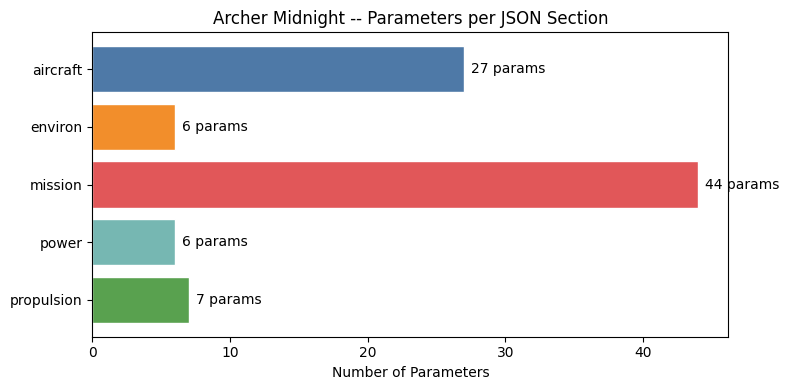

In [2]:
import matplotlib.pyplot as plt

sections = list(config.keys())
counts = [len(config[s]) for s in sections]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sections, counts, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'],
               edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{count} params', va='center', fontsize=10)
ax.set_xlabel('Number of Parameters')
ax.set_title('Archer Midnight -- Parameters per JSON Section')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Aircraft Section

The `aircraft` section defines the vehicle geometry, aerodynamics, and fixed mass components.

In [3]:
for key, value in config['aircraft'].items():
    print(f"  {key:45s} = {value}")

  max_takeoff_mass_kg                           = 2948.35
  payload_kg                                    = 453.0
  vehicle_cl_max                                = 1.5
  wing_taper_ratio                              = 0.4
  wingspan_m                                    = 15.24
  d_value_m                                     = 15.24
  stall_speed_m_p_s                             = 40.0
  fuselage_l_m                                  = 9.0
  fuselage_w_m                                  = 1.6
  fuselage_h_m                                  = 1.6
  wing_airfoil_cd_at_cruise_cl                  = 0.0065
  empennage_airfoil_cd0                         = 0.01
  span_effic_factor                             = 0.8
  trim_drag_factor                              = 1.05
  landing_gear_drag_area_m2                     = 0.07
  excres_protub_factor                          = 1.03
  horiz_tail_vol_coeff                          = 0.7
  vert_tail_vol_coeff                           = 0.05
  ratio_d

### Key Aircraft Parameters

The aircraft section contains geometry, aerodynamics, and fixed mass components. Many of these parameters feed directly into the sizing equations:

| Parameter | Description | Units | Role in Computation |
|---|---|---|---|
| `max_takeoff_mass_kg` | Initial MTOW guess (iteratively updated) | kg | Drives wing area, hover thrust, battery sizing |
| `payload_kg` | Useful payload (passengers + cargo) | kg | Fixed constraint on the design |
| `wingspan_m` | Wing tip-to-tip span | m | Determines aspect ratio and induced drag |
| `vehicle_cl_max` | Maximum lift coefficient | - | Sets wing area via stall speed equation |
| `stall_speed_m_p_s` | Stall speed at sea level | m/s | Sets wing area: $S = 2mg / (\rho V_{stall}^2 C_{L,max})$ |
| `fuselage_l_m`, `fuselage_w_m`, `fuselage_h_m` | Fuselage dimensions | m | Drive fuselage drag (Hoerner's equations) |
| `wing_airfoil_cd_at_cruise_cl` | Wing airfoil profile drag at cruise CL | - | Added to cruise drag buildup |
| `span_effic_factor` | Oswald span efficiency factor (typical: 0.7-0.9) | - | Scales induced drag: $C_{D_i} = C_L^2 / (\pi \cdot AR \cdot e)$ |
| `mass_margin_factor` | Mass margin applied to empty weight (e.g. 0.10 = 10%) | - | Accounts for uncertainties in early design |

## Environ Section

Atmospheric conditions at sea level and maximum altitude.

In [4]:
for key, value in config['environ'].items():
    print(f"  {key:45s} = {value}")

  g_m_p_s2                                      = 9.81
  sound_speed_m_p_s                             = 340.0
  air_density_sea_lvl_kg_p_m3                   = 1.225
  air_density_max_alt_kg_p_m3                   = 1.056
  kinematic_viscosity_sea_lvl_m2_p_s            = 1.46e-05
  kinematic_viscosity_max_alt_m2_p_s            = 1.5e-05


## Mission Section

The mission section defines **11 primary flight segments** and **7 reserve segments**. Each segment specifies an average velocity and a duration. The baseline mission profile is adapted from [Uber Elevate's *UberAir Vehicle Requirements and Mission*](../../references/summary-mission-and-requirements.pdf). It should be noted that the user could add/ modify the mission as they see fit.

The segments fall into three power categories:

| Category | Segments | Power Model |
|---|---|---|
| **Hover-only** | Taxi, Hover Climb/Descend | Momentum theory: $P = T \cdot v_i$ where $v_i = \sqrt{T/(2\rho A)}$ |
| **Wing-borne** | Procedures, Cruise | Drag-based: $P = D \cdot v / \eta_{rotor}$ |
| **Transition** | Trans. Climb/Descend, Accel/Decel | Combined hover assist + aerodynamic drag |

Each segment's power calculation is detailed in the theory document (`docs/theory/evtol-sizing.md`).

In [5]:
print(f"Total mission parameters: {len(config['mission'])}")
print("\nPrimary segments:")
for key, value in config['mission'].items():
    if not key.startswith('reserve'):
        print(f"  {key:45s} = {value}")

Total mission parameters: 44

Primary segments:
  depart_taxi_avg_h_m_p_s                       = 1.34
  depart_taxi_s                                 = 30.0
  hover_climb_avg_v_m_p_s                       = 2.54
  hover_climb_s                                 = 45.0
  trans_climb_avg_h_m_p_s                       = 24.4
  trans_climb_v_m_p_s                           = 5.1
  trans_climb_s                                 = 15.0
  depart_proc_h_m_p_s                           = 48.7
  depart_proc_s                                 = 18.0
  accel_climb_avg_h_m_p_s                       = 57.9
  accel_climb_v_m_p_s                           = 5.1
  accel_climb_s                                 = 72.0
  cruise_h_m_p_s                                = 66.9444
  cruise_s                                      = 558.0
  decel_descend_avg_h_m_p_s                     = 57.9
  decel_descend_v_m_p_s                         = 5.1
  decel_descend_s                               = 72.0
  arrive_proc_h_

## Power and Propulsion Sections

In [6]:
print("--- Power ---")
for key, value in config['power'].items():
    print(f"  {key:45s} = {value}")

print("\n--- Propulsion ---")
for key, value in config['propulsion'].items():
    print(f"  {key:45s} = {value}")

--- Power ---
  batt_spec_energy_w_h_p_kg                     = 256.0
  batt_inaccessible_energy_frac                 = 0.05
  batt_eol_capacity                             = 0.8
  batt_int_factor                               = 0.8
  epu_effic                                     = 0.92
  hover_power_effic                             = 0.74

--- Propulsion ---
  rotor_effic                                   = 0.8
  rotor_count                                   = 12
  lift_rotor_count                              = 6
  tilt_rotor_count                              = 6
  rotor_diameter_m                              = 2.0
  tip_mach                                      = 0.52
  rotor_avg_cl                                  = 0.6


## Summary

The JSON configuration has five sections:

1. **aircraft** - Geometry, aerodynamics, and fixed mass components
2. **environ** - Atmospheric conditions
3. **mission** - Flight segment velocities and durations
4. **power** - Battery and EPU specifications
5. **propulsion** - Rotor system parameters


**Next:** Move on to [02 - Aircraft Configuration] for a deeper dive into the aircraft configuration.